# Week 1.2: LLM Big Picture & Anatomy for Digital Twins

## Learning Objectives
- Understand the overall architecture of LLMs
- Learn about tokens, tokenization, and embeddings
- See how different components work together
- Apply these concepts to building a language-enabled digital twin

## Key Insight
> "Know the different bits of the LLM architecture and how they work together to generate outputs."

## Digital Twin Context
Today we'll enhance our digital twin with language understanding capabilities. By the end, your digital twin will:
- Convert text to numerical representations
- Understand word relationships and context
- Process sequences of information

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import re

# Set style
sns.set_style('whitegrid')
np.random.seed(42)

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


---
## Part 1: Tokenization - Breaking Text into Pieces

Before an LLM can process text, it needs to convert words into tokens.

### 1.1 Simple Word Tokenization

In [2]:
def simple_tokenize(text):
    """
    Basic tokenization: split text into words.

    Args:
        text: Input string

    Returns:
        list: Tokens
    """
    # Convert to lowercase and split
    text = text.lower()
    # Remove punctuation and split
    tokens = re.findall(r'\b\w+\b', text)
    return tokens

# Example: Digital twin's user description
user_description = """
I love running in the morning before work. Coffee is essential.
I enjoy reading science fiction and coding in Python.
Weekends are for family time and outdoor activities.
"""

tokens = simple_tokenize(user_description)
print("Original text:")
print(user_description)
print(f"\nTokens ({len(tokens)} total):")
print(tokens[:20], "...")  # Show first 20

# Count token frequencies
token_counts = Counter(tokens)
print("\nMost common tokens:")
for token, count in token_counts.most_common(10):
    print(f"  {token}: {count}")

Original text:

I love running in the morning before work. Coffee is essential. 
I enjoy reading science fiction and coding in Python. 
Weekends are for family time and outdoor activities.


Tokens (28 total):
['i', 'love', 'running', 'in', 'the', 'morning', 'before', 'work', 'coffee', 'is', 'essential', 'i', 'enjoy', 'reading', 'science', 'fiction', 'and', 'coding', 'in', 'python'] ...

Most common tokens:
  i: 2
  in: 2
  and: 2
  love: 1
  running: 1
  the: 1
  morning: 1
  before: 1
  work: 1
  coffee: 1


### 🎯 Exercise 1.1 (Easy): Personal Tokenization

**Task**: Write a short description of yourself (3-4 sentences) and tokenize it.

**Questions**:
1. How many unique tokens do you have?
2. What are your most frequent tokens?
3. How does tokenization help the digital twin understand you?

In [4]:
# YOUR CODE HERE
my_description = """
I am a young male. I enjoy running as a healthy hobby. My passion is in my faith and coding.
"""

# Tokenize and analyze
my_tokens = simple_tokenize(my_description)

# Your analysis:
print(f"Total tokens: {len(my_tokens)}")
print(f"Unique tokens: {len(set(my_tokens))}")

# Add more analysis

# Count token frequencies
my_token_counts = Counter(my_tokens)

print(f"Most common tokens:")
for token, count in Counter(my_tokens).most_common(10):
    print(f"  {token}: {count}")

#1. I have 17 Unique tokens.
#2. My most frequent tokens are: I=2, a=2, my=2.
#3. By looking at the tokens and their frequencies, the digital twin can identify important information about my interests, such as running, coding, faith, and having a healthy lifestyle.


Total tokens: 20
Unique tokens: 17
Most common tokens:
  i: 2
  a: 2
  my: 2
  am: 1
  young: 1
  male: 1
  enjoy: 1
  running: 1
  as: 1
  healthy: 1


### 1.2 Subword Tokenization (BPE-like)

Real LLMs use subword tokenization to handle rare words and morphology.

In [5]:
class SimpleTokenizer:
    """Simple subword tokenizer inspired by BPE."""

    def __init__(self, vocab_size=100):
        self.vocab_size = vocab_size
        self.word_to_id = {}
        self.id_to_word = {}
        self.subword_vocab = []

    def build_vocab(self, texts):
        """
        Build vocabulary from texts.

        Args:
            texts: List of text strings
        """
        # Get all words
        all_words = []
        for text in texts:
            all_words.extend(simple_tokenize(text))

        # Count frequencies
        word_counts = Counter(all_words)

        # Take most common words
        most_common = word_counts.most_common(self.vocab_size)

        # Build vocabulary
        special_tokens = ['<PAD>', '<UNK>', '<START>', '<END>']
        self.word_to_id = {word: i for i, word in enumerate(special_tokens)}

        for i, (word, count) in enumerate(most_common):
            self.word_to_id[word] = i + len(special_tokens)

        self.id_to_word = {i: word for word, i in self.word_to_id.items()}

        print(f"Vocabulary built: {len(self.word_to_id)} tokens")

    def encode(self, text):
        """
        Convert text to token IDs.

        Args:
            text: Input string

        Returns:
            list: Token IDs
        """
        tokens = simple_tokenize(text)
        unk_id = self.word_to_id['<UNK>']
        return [self.word_to_id.get(token, unk_id) for token in tokens]

    def decode(self, token_ids):
        """
        Convert token IDs back to text.

        Args:
            token_ids: List of token IDs

        Returns:
            str: Decoded text
        """
        tokens = [self.id_to_word.get(id, '<UNK>') for id in token_ids]
        # Filter special tokens
        tokens = [t for t in tokens if not t.startswith('<')]
        return ' '.join(tokens)

# Build tokenizer for digital twin
training_texts = [
    user_description,
    "I prefer tea over coffee in the afternoon",
    "Running helps me stay focused and energized",
    "Python is my favorite programming language",
    "I love spending time with family on weekends",
]

tokenizer = SimpleTokenizer(vocab_size=50)
tokenizer.build_vocab(training_texts)

# Test encoding and decoding
test_text = "I love running and coding in Python"
encoded = tokenizer.encode(test_text)
decoded = tokenizer.decode(encoded)

print(f"\nOriginal: {test_text}")
print(f"Encoded: {encoded}")
print(f"Decoded: {decoded}")

Vocabulary built: 45 tokens

Original: I love running and coding in Python
Encoded: [4, 7, 8, 6, 24, 5, 12]
Decoded: i love running and coding in python


### 🎯 Exercise 1.2 (Intermediate): Vocabulary Analysis

**Task**: Analyze what happens with different vocabulary sizes.

**Questions**:
1. What happens when you use a very small vocabulary (vocab_size=10)?
2. How many unknown tokens do you get?
3. What's the trade-off between vocabulary size and coverage?

In [18]:
# YOUR CODE HERE
# Experiment with different vocabulary sizes

vocab_sizes = [10, 20, 50, 100]
test_texts = [
    "I love running and programming",
    "Coffee is essential for productivity",
    "Weekend activities include hiking and reading",
]

# For each vocabulary size, count unknown tokens
results = []
for size in vocab_sizes:
    # Create tokenizer
    tokenizer = SimpleTokenizer(vocab_size=size)
    tokenizer.build_vocab(training_texts)

    # Count unknowns
    unk_count = 0
    total_tokens = 0

    for text in test_texts:
        encoded = tokenizer.encode(text)
        unk_id = tokenizer.word_to_id['<UNK>']

        unk_count += encoded.count(unk_id)
        total_tokens += len(encoded)

    # Store results
    results.append({
        'vocab_size': size,
        'unknown_tokens': unk_count,
        'total_tokens': total_tokens
    })

# Visualize results
for result in results:
    print(
        f"Vocabulary size: {result['vocab_size']}, "
        f"Unknown tokens: {result['unknown_tokens']} "
        f"out of {result['total_tokens']}"
    )

#1. Only the most frequent words are included in the vocabulary. Words that aren't among those 10 words are converted to unknown.
#2. The number depends on the vocabulary built: 10=9; 20=7; 50=4; 100=4.
#3. A smaller vocabulary uses less memory and is simpler, but it has lower coverage and produces more unknown tokens. A larger vocabulary provides better coverage and fewer unknown tokens, but requires more memory and increases the size of the vocabulary the model needs to work with.

Vocabulary built: 14 tokens
Vocabulary built: 24 tokens
Vocabulary built: 45 tokens
Vocabulary built: 45 tokens
Vocabulary size: 10, Unknown tokens: 9 out of 16
Vocabulary size: 20, Unknown tokens: 7 out of 16
Vocabulary size: 50, Unknown tokens: 4 out of 16
Vocabulary size: 100, Unknown tokens: 4 out of 16


---
## Part 2: Embeddings - Giving Meaning to Tokens

Embeddings convert tokens into dense vectors that capture semantic meaning.

### 2.1 Creating Simple Embeddings

In [19]:
class SimpleEmbedding:
    """Simple word embedding layer."""

    def __init__(self, vocab_size, embedding_dim):
        """
        Initialize embedding matrix.

        Args:
            vocab_size: Size of vocabulary
            embedding_dim: Dimension of embedding vectors
        """
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        # Initialize with random values
        self.embeddings = np.random.randn(vocab_size, embedding_dim) * 0.1

    def embed(self, token_ids):
        """
        Get embeddings for token IDs.

        Args:
            token_ids: List of token IDs

        Returns:
            np.array: Embedding vectors
        """
        return self.embeddings[token_ids]

    def similarity(self, id1, id2):
        """
        Calculate cosine similarity between two tokens.

        Args:
            id1, id2: Token IDs

        Returns:
            float: Cosine similarity
        """
        vec1 = self.embeddings[id1]
        vec2 = self.embeddings[id2]

        # Cosine similarity
        dot_product = np.dot(vec1, vec2)
        norm1 = np.linalg.norm(vec1)
        norm2 = np.linalg.norm(vec2)

        return dot_product / (norm1 * norm2)

# Create embeddings for our vocabulary
vocab_size = len(tokenizer.word_to_id)
embedding_dim = 16  # Small dimension for visualization

embedding_layer = SimpleEmbedding(vocab_size, embedding_dim)

# Test with some words
test_words = ['running', 'coding', 'coffee', 'python', 'family']
print("Word embeddings:")
for word in test_words:
    if word in tokenizer.word_to_id:
        token_id = tokenizer.word_to_id[word]
        embedding = embedding_layer.embed([token_id])[0]
        print(f"\n{word} (ID: {token_id}):")
        print(f"  Embedding (first 5 dims): {embedding[:5]}")
        print(f"  Norm: {np.linalg.norm(embedding):.3f}")

Word embeddings:

running (ID: 8):
  Embedding (first 5 dims): [ 0.00996514 -0.05034757 -0.15506634  0.0068563  -0.10623037]
  Norm: 0.381

coding (ID: 24):
  Embedding (first 5 dims): [-0.07591327  0.01503938  0.0341756   0.18761708  0.09504238]
  Norm: 0.442

coffee (ID: 10):
  Embedding (first 5 dims): [-0.09746817  0.07870846  0.11585956 -0.08206823  0.09633761]
  Norm: 0.345

python (ID: 12):
  Embedding (first 5 dims): [ 0.02140937 -0.12457388  0.01731809  0.03853174 -0.08838574]
  Norm: 0.315

family (ID: 14):
  Embedding (first 5 dims): [-0.04719319  0.10889506  0.006428   -0.10777448 -0.07153037]
  Norm: 0.385


### 2.2 Training Embeddings with Context

Embeddings learn meaning from co-occurrence patterns (Word2Vec style).

In [20]:
def train_embeddings(tokenizer, texts, embedding_dim=16, window_size=2,
                     learning_rate=0.01, epochs=100):
    """
    Train embeddings using skip-gram approach.

    Args:
        tokenizer: Tokenizer instance
        texts: List of training texts
        embedding_dim: Dimension of embeddings
        window_size: Context window size
        learning_rate: Learning rate
        epochs: Number of training epochs

    Returns:
        SimpleEmbedding: Trained embedding layer
    """
    vocab_size = len(tokenizer.word_to_id)
    embeddings = SimpleEmbedding(vocab_size, embedding_dim)

    # Create training pairs (center word, context word)
    training_pairs = []
    for text in texts:
        token_ids = tokenizer.encode(text)
        for i, center_id in enumerate(token_ids):
            # Get context window
            start = max(0, i - window_size)
            end = min(len(token_ids), i + window_size + 1)
            context_ids = [token_ids[j] for j in range(start, end) if j != i]
            for context_id in context_ids:
                training_pairs.append((center_id, context_id))

    print(f"Training on {len(training_pairs)} word pairs...")

    # Simple training loop
    for epoch in range(epochs):
        total_loss = 0
        np.random.shuffle(training_pairs)

        for center_id, context_id in training_pairs:
            # Get embeddings
            center_emb = embeddings.embeddings[center_id]
            context_emb = embeddings.embeddings[context_id]

            # Calculate similarity
            similarity = np.dot(center_emb, context_emb)

            # Gradient descent (simplified)
            gradient = context_emb - similarity * center_emb
            embeddings.embeddings[center_id] += learning_rate * gradient

            total_loss += (1 - similarity) ** 2

        if epoch % 20 == 0:
            avg_loss = total_loss / len(training_pairs)
            print(f"Epoch {epoch}: Loss = {avg_loss:.4f}")

    return embeddings

# Train embeddings
trained_embeddings = train_embeddings(tokenizer, training_texts,
                                     embedding_dim=16, epochs=100)

print("\n✅ Embeddings trained!")

Training on 198 word pairs...
Epoch 0: Loss = 0.9954
Epoch 20: Loss = 0.7512
Epoch 40: Loss = 0.2963
Epoch 60: Loss = 0.0714
Epoch 80: Loss = 0.0170

✅ Embeddings trained!


In [21]:
# Test similarity after training
def find_similar_words(word, tokenizer, embeddings, top_k=5):
    """
    Find most similar words to given word.

    Args:
        word: Query word
        tokenizer: Tokenizer instance
        embeddings: Embedding layer
        top_k: Number of similar words to return

    Returns:
        list: Similar words with similarities
    """
    if word not in tokenizer.word_to_id:
        return None

    word_id = tokenizer.word_to_id[word]
    word_emb = embeddings.embeddings[word_id]

    # Calculate similarities with all words
    similarities = []
    for other_word, other_id in tokenizer.word_to_id.items():
        if other_word.startswith('<') or other_id == word_id:
            continue
        sim = embeddings.similarity(word_id, other_id)
        similarities.append((other_word, sim))

    # Sort by similarity
    similarities.sort(key=lambda x: x[1], reverse=True)
    return similarities[:top_k]

# Test with some words
test_words = ['running', 'python', 'coffee', 'love']
for word in test_words:
    similar = find_similar_words(word, tokenizer, trained_embeddings)
    if similar:
        print(f"\nWords similar to '{word}':")
        for similar_word, sim in similar:
            print(f"  {similar_word}: {sim:.3f}")


Words similar to 'running':
  love: 0.977
  in: 0.974
  coding: 0.960
  the: 0.947
  i: 0.945

Words similar to 'python':
  in: 0.980
  love: 0.966
  coding: 0.963
  spending: 0.943
  running: 0.943

Words similar to 'coffee':
  work: 0.982
  is: 0.979
  over: 0.979
  the: 0.975
  before: 0.966

Words similar to 'love':
  spending: 0.978
  running: 0.977
  i: 0.976
  in: 0.974
  python: 0.966


### 🎯 Exercise 2.1 (Intermediate): Embedding Visualization

**Task**: Visualize word embeddings in 2D space using dimensionality reduction.

**Steps**:
1. Use PCA or t-SNE to reduce embeddings to 2D
2. Plot the words
3. Identify clusters of related words

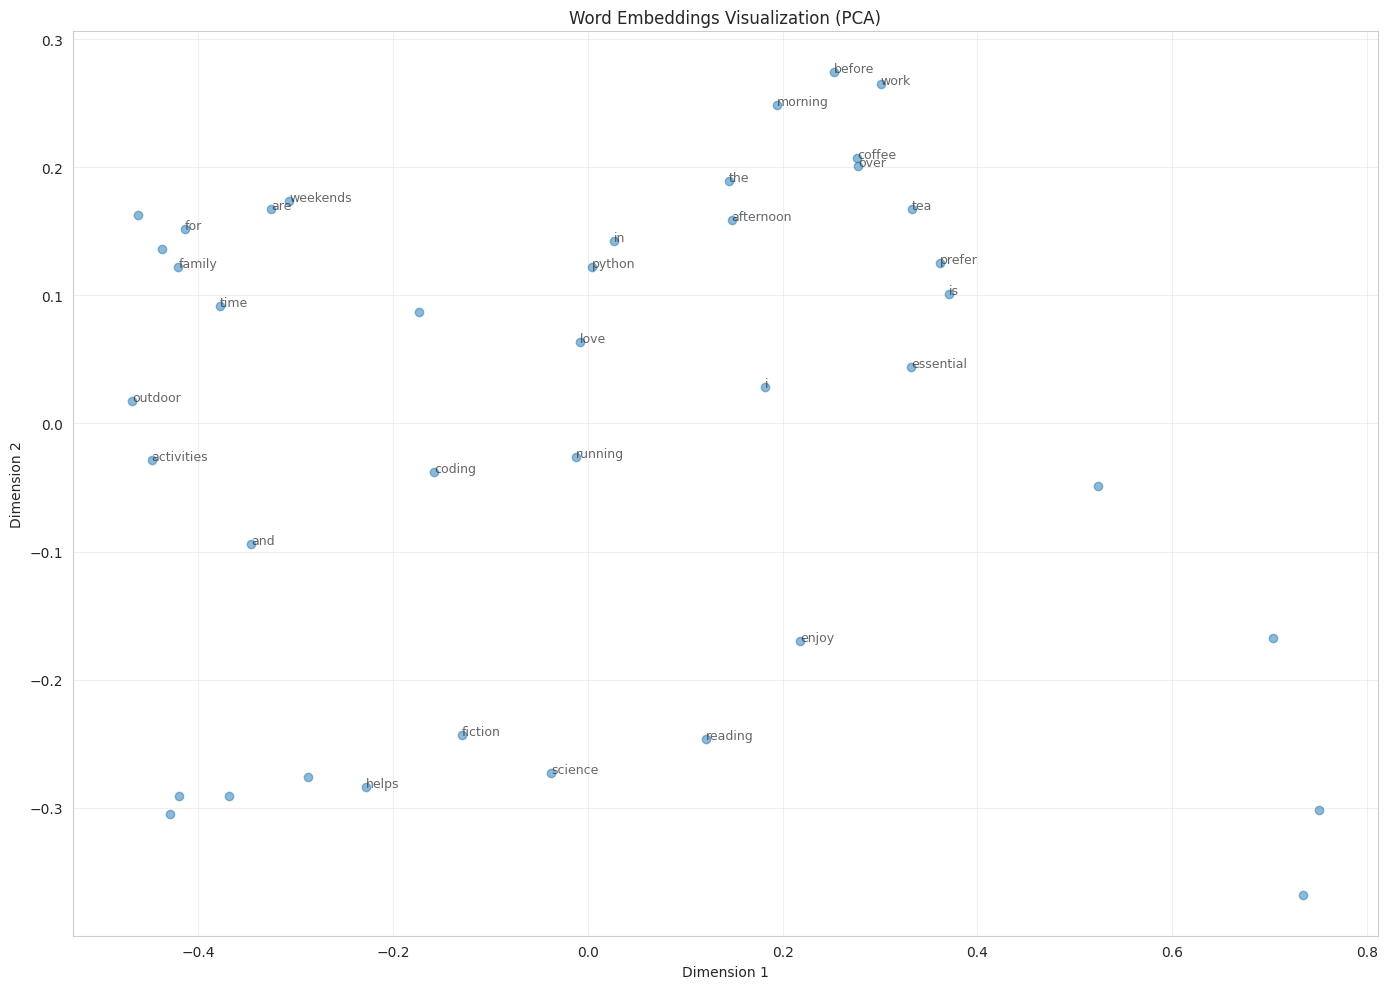

In [22]:
# YOUR CODE HERE
def visualize_embeddings(tokenizer, embeddings, method='pca'):
    """
    Visualize embeddings in 2D.

    Args:
        tokenizer: Tokenizer instance
        embeddings: Embedding layer
        method: 'pca' or 'tsne'
    """
    # Get all embeddings (excluding special tokens)
    words = []
    vectors = []

    for word, idx in tokenizer.word_to_id.items():
        if not word.startswith('<'):
            words.append(word)
            vectors.append(embeddings.embeddings[idx])

    vectors = np.array(vectors)

    # Reduce dimensionality
    if method == 'pca':
        reducer = PCA(n_components=2)
    else:
        reducer = TSNE(n_components=2, random_state=42)

    coords_2d = reducer.fit_transform(vectors)

    # Plot
    plt.figure(figsize=(14, 10))
    plt.scatter(coords_2d[:, 0], coords_2d[:, 1], alpha=0.5)

    # Annotate words
    for i, word in enumerate(words[:30]):  # Show first 30 to avoid clutter
        plt.annotate(word, (coords_2d[i, 0], coords_2d[i, 1]),
                    fontsize=9, alpha=0.7)

    plt.title(f'Word Embeddings Visualization ({method.upper()})')
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Visualize
visualize_embeddings(tokenizer, trained_embeddings, method='pca')

#Answer.
# The 2D visualization shows how the trained word embeddings are positioned relative to each other. Words that occur in similar contexts may appear closer together, which can form clusters of related concepts such as programming, activities, or drinks. Because this model was trained on a small dataset, the clusters may not be perfectly separated.

---
## Part 3: LLM Architecture Overview

Now let's see how these components fit into the bigger picture.

### 3.1 The LLM Pipeline

In [23]:
class SimpleLLMPipeline:
    """
    Simplified LLM pipeline showing major components.
    """

    def __init__(self, tokenizer, embeddings):
        self.tokenizer = tokenizer
        self.embeddings = embeddings
        self.processing_steps = []

    def process(self, text, verbose=True):
        """
        Process text through the pipeline.

        Args:
            text: Input text
            verbose: Print intermediate steps

        Returns:
            dict: Processing results
        """
        results = {}

        # Step 1: Tokenization
        if verbose:
            print("Step 1: Tokenization")
            print("  Input text:", text)

        tokens = simple_tokenize(text)
        token_ids = self.tokenizer.encode(text)

        if verbose:
            print(f"  Tokens: {tokens}")
            print(f"  Token IDs: {token_ids}")

        results['tokens'] = tokens
        results['token_ids'] = token_ids

        # Step 2: Embedding
        if verbose:
            print("\nStep 2: Embedding")

        embedded = self.embeddings.embed(token_ids)

        if verbose:
            print(f"  Embedding shape: {embedded.shape}")
            print(f"  (sequence_length={len(token_ids)}, embedding_dim={embedded.shape[1]})")

        results['embeddings'] = embedded

        # Step 3: Attention (simplified - just mean pooling)
        if verbose:
            print("\nStep 3: Contextual Processing (Simplified)")

        # Simple mean pooling as placeholder
        contextualized = np.mean(embedded, axis=0)

        if verbose:
            print(f"  Contextualized representation shape: {contextualized.shape}")

        results['contextualized'] = contextualized

        # Step 4: Output projection (simplified)
        if verbose:
            print("\nStep 4: Output Generation (Simplified)")
            print("  → In real LLMs, this produces probability distribution over vocabulary")

        return results

# Create pipeline
pipeline = SimpleLLMPipeline(tokenizer, trained_embeddings)

# Test with digital twin input
test_input = "I love running and coding"
print("=" * 60)
print("PROCESSING THROUGH LLM PIPELINE")
print("=" * 60 + "\n")

results = pipeline.process(test_input, verbose=True)

print("\n" + "=" * 60)
print("✅ Processing complete!")
print("=" * 60)

PROCESSING THROUGH LLM PIPELINE

Step 1: Tokenization
  Input text: I love running and coding
  Tokens: ['i', 'love', 'running', 'and', 'coding']
  Token IDs: [4, 7, 8, 6, 24]

Step 2: Embedding
  Embedding shape: (5, 16)
  (sequence_length=5, embedding_dim=16)

Step 3: Contextual Processing (Simplified)
  Contextualized representation shape: (16,)

Step 4: Output Generation (Simplified)
  → In real LLMs, this produces probability distribution over vocabulary

✅ Processing complete!


### 🎯 Exercise 3.1 (Conceptual): Architecture Understanding

**Questions**:

1. Why is tokenization necessary before embedding?
2. What information is captured in embeddings?
3. What would happen if we skipped the embedding step and used one-hot encoding instead?
4. How does sequence length affect computational cost?
5. In a real LLM, what happens after the "contextual processing" step?

Write your answers below:

**Your Answers:**

1. Why tokenization is necessary:
   - Tokenization converts text into smaller units, such as words or subwords, that the model can work with. These tokens are then mapped to numerical IDs, which can be used to look up their corresponding embedding vectors. Without tokenization, the text cannot be directly converted into the numerical representation needed by the model.

2. Information in embeddings:
   - Embeddings represent tokens as numerical vectors that capture semantic meaning and relationships between words. Words that have similar meanings or appear in similar contexts can have similar vector representations.

3. One-hot encoding vs embeddings:
   - Each token would be represented by a large vector containing mostly zeros, with a single 1 representing that token. One-hot encoding identifies tokens but does not capture semantic relationships between them. It is also much less efficient than dense embeddings because the vectors can become very large as the vocabulary grows.

4. Sequence length impact:
   - As the sequence gets longer, the model has more tokens to process, so computational and memory requirements increase. In particular, self-attention becomes significantly more expensive as sequence length increases because tokens need to consider their relationships with other tokens.

5. After contextual processing:
   - After contextual processing, the model uses the resulting representations to produce scores/probabilities for possible next tokens. The model then selects or samples a token based on those probabilities. This process is repeated token by token to generate the response.

### 3.2 Comparing Different Embedding Dimensions

In [24]:
# Experiment with different embedding dimensions
dimensions = [4, 8, 16, 32]

print("Comparing embedding dimensions:\n")
for dim in dimensions:
    emb = SimpleEmbedding(vocab_size, dim)

    # Calculate memory usage
    memory_mb = (vocab_size * dim * 4) / (1024 * 1024)  # 4 bytes per float

    print(f"Dimension {dim}:")
    print(f"  Parameters: {vocab_size * dim:,}")
    print(f"  Memory: {memory_mb:.2f} MB")
    print(f"  Expressiveness: {'Low' if dim < 16 else 'Medium' if dim < 64 else 'High'}")
    print()

Comparing embedding dimensions:

Dimension 4:
  Parameters: 180
  Memory: 0.00 MB
  Expressiveness: Low

Dimension 8:
  Parameters: 360
  Memory: 0.00 MB
  Expressiveness: Low

Dimension 16:
  Parameters: 720
  Memory: 0.00 MB
  Expressiveness: Medium

Dimension 32:
  Parameters: 1,440
  Memory: 0.01 MB
  Expressiveness: Medium



### 🎯 Exercise 3.2 (Advanced): Build a Mini Language Model

**Task**: Create a simple language model that can predict the next word.

**Requirements**:
1. Use the tokenizer and embeddings we created
2. Implement a simple prediction mechanism
3. Test with different input sequences
4. Measure prediction accuracy

**Hint**: You can use the embeddings to find the most similar word to a context representation.

In [33]:
# YOUR CODE HERE
class MiniLanguageModel:
    """
    Simple language model for next word prediction.
    """

    def __init__(self, tokenizer, embeddings):
        self.tokenizer = tokenizer
        self.embeddings = embeddings
        # Build context patterns from training data
        self.context_patterns = self._build_patterns()

    def _build_patterns(self):
        """Build context → next word patterns from training data."""
        # YOUR CODE HERE
        patterns = {}

        for text in training_texts:
            tokens = simple_tokenize(text)

            for i in range(len(tokens) - 1):
                context = tokens[i]
                next_word = tokens[i + 1]

                if context not in patterns:
                    patterns[context] = []

                patterns[context].append(next_word)

        return patterns

    def predict_next_word(self, context):
        """
        Predict the most likely next word.

        Args:
            context: String of context words

        Returns:
            str: Predicted next word
        """
        # YOUR CODE HERE
        tokens = simple_tokenize(context)

        if not tokens:
            return None

        # Use the last word as the context
        current_word = tokens[-1]

        # If we have seen this word during training,
        # predict the most common word that follows it
        if current_word in self.context_patterns:
            next_words = self.context_patterns[current_word]
            counts = Counter(next_words)
            return counts.most_common(1)[0][0]

        # If the word is unknown, return None
        return None

    def generate_sequence(self, start_text, num_words=5):
        """
        Generate a sequence of words.

        Args:
            start_text: Starting context
            num_words: Number of words to generate

        Returns:
            str: Generated text
        """
        # YOUR CODE HERE
        generated_text = start_text

        for _ in range(num_words):
            next_word = self.predict_next_word(generated_text)

            if next_word is None:
                break

            generated_text += " " + next_word

        return generated_text

        # Create your model
        model = MiniLanguageModel(tokenizer, trained_embeddings)

        # Measure prediction accuracy
        def calculate_accuracy(model, texts):
            correct = 0
            total = 0

            for text in texts:
                tokens = simple_tokenize(text)

                for i in range(len(tokens) - 1):
                    context = tokens[i]
                    actual_next = tokens[i + 1]

                    predicted_next = model.predict_next_word(context)

                    if predicted_next == actual_next:
                        correct += 1

                    total += 1

            accuracy = correct / total if total > 0 else 0
            return accuracy


# Test prediction accuracy
accuracy = calculate_accuracy(model, training_texts)

print(f"\nPrediction Accuracy: {accuracy:.2%}")

# Test your model
#model = MiniLanguageModel(tokenizer, trained_embeddings)

prediction = model.predict_next_word("I love")
print(f"Next word prediction: {prediction}")

generated = model.generate_sequence("I love", num_words=5)
print(f"Generated sequence: {generated}")


Prediction Accuracy: 75.00%
Next word prediction: running
Generated sequence: I love running in the morning before


---
## Part 4: Digital Twin Integration

Let's bring everything together for our digital twin!

### 4.1 Digital Twin Language Encoder

In [43]:
class DigitalTwinEncoder:
    """
    Encode user descriptions into vector representations.
    """

    def __init__(self, tokenizer, embeddings):
        self.tokenizer = tokenizer
        self.embeddings = embeddings
        self.user_profile = None

    def encode_user(self, description):
        """
        Encode user description into a profile vector.

        Args:
            description: User description text

        Returns:
            np.array: User profile vector
        """
        # Tokenize
        token_ids = self.tokenizer.encode(description)

        # Embed
        embedded = self.embeddings.embed(token_ids)

        # Pool (mean pooling)
        profile = np.mean(embedded, axis=0)

        self.user_profile = profile
        return profile

    def compare_descriptions(self, desc1, desc2):
        """
        Compare similarity between two descriptions.

        Args:
            desc1, desc2: Description texts

        Returns:
            float: Similarity score
        """
        profile1 = self.encode_user(desc1)
        profile2 = self.encode_user(desc2)

        # Cosine similarity
        similarity = np.dot(profile1, profile2) / (
            np.linalg.norm(profile1) * np.linalg.norm(profile2)
        )

        return similarity

    def find_interests(self, description):
        """
        Extract key interests from description.

        Args:
            description: User description

        Returns:
            list: Key interest words
        """
        tokens = simple_tokenize(description)
        token_ids = self.tokenizer.encode(description)

        # Get embeddings
        embedded = self.embeddings.embed(token_ids)

        # Find tokens with highest norm (most "important")
        norms = np.linalg.norm(embedded, axis=1)
        top_indices = np.argsort(norms)[-5:][::-1]

        interests = [tokens[i] for i in top_indices if i < len(tokens)]
        return interests

# Create digital twin encoder
twin_encoder = DigitalTwinEncoder(tokenizer, trained_embeddings)

# Test with different user profiles
user1 = "I love running and outdoor sports. Coffee enthusiast."
user2 = "I enjoy coding in Python and building AI systems."
user3 = "I love running and coding in Python."

print("User Profile Encoding:\n")
profile1 = twin_encoder.encode_user(user1)
print(f"User 1 profile shape: {profile1.shape}")
print(f"Profile vector (first 8 dims): {profile1[:8]}")

print("\n" + "="*60)
print("Comparing User Profiles:\n")

sim_1_2 = twin_encoder.compare_descriptions(user1, user2)
sim_1_3 = twin_encoder.compare_descriptions(user1, user3)
sim_2_3 = twin_encoder.compare_descriptions(user2, user3)

print(f"User 1 vs User 2 similarity: {sim_1_2:.3f}")
print(f"User 1 vs User 3 similarity: {sim_1_3:.3f}")
print(f"User 2 vs User 3 similarity: {sim_2_3:.3f}")

print("\n" + "="*60)
print("Detected Interests:\n")

for i, user in enumerate([user1, user2, user3], 1):
    interests = twin_encoder.find_interests(user)
    print(f"User {i}: {interests}")

User Profile Encoding:

User 1 profile shape: (16,)
Profile vector (first 8 dims): [ 0.33866163 -0.07237815  0.13469448  0.21867139 -0.04905753  0.12383126
  0.24739396 -0.10105272]

Comparing User Profiles:

User 1 vs User 2 similarity: 0.985
User 1 vs User 3 similarity: 0.988
User 2 vs User 3 similarity: 0.968

Detected Interests:

User 1: ['and', 'i', 'coffee', 'running', 'love']
User 2: ['and', 'in', 'i', 'python', 'enjoy']
User 3: ['and', 'in', 'i', 'running', 'love']


### 🎯 Exercise 4.1 (Intermediate): Build Your Digital Twin Profile

**Task**: Create and analyze your own digital twin profile.

**Steps**:
1. Write a detailed description of yourself (interests, habits, preferences)
2. Encode it using the digital twin encoder
3. Compare it with other example profiles
4. Identify detected interests
5. Test how similar descriptions affect similarity scores

In [45]:
# YOUR CODE HERE
my_description = """
I am a young ambitious student, studying to become a professional coder and AI specialist. My interests are coding, design and development. My habits are things like running marathons, exercising in the afternoon and having good relationships. I prefer a quiet space more than a noisy space as well as peace over chaos.
"""

# Encode your profile
my_profile = twin_encoder.encode_user(my_description)

print("My Digital Twin Profile:")
print(f"Profile shape: {my_profile.shape}")
print(f"Profile vector (first 8 dims): {my_profile[:8]}")

# Compare with examples
print("\n" + "="*60)
print("Comparing My Profile with Examples:\n")

sim_my_user1 = twin_encoder.compare_descriptions(my_description, user1)
sim_my_user2 = twin_encoder.compare_descriptions(my_description, user2)
sim_my_user3 = twin_encoder.compare_descriptions(my_description, user3)

print(f"My profile vs User 1 similarity: {sim_my_user1:.3f}")
print(f"My profile vs User 2 similarity: {sim_my_user2:.3f}")
print(f"My profile vs User 3 similarity: {sim_my_user3:.3f}")

# Find your interests
def get_my_interests(description):
    """
    Extract interests from statements about the user's interests.
    """

    tokens = simple_tokenize(description)
    interests = []

    # Look for "my interests are..."
    if 'interests' in tokens:
        interest_index = tokens.index('interests')

        # Check that "interests" is followed by "are"
        if interest_index + 1 < len(tokens) and tokens[interest_index + 1] == 'are':

            # Start collecting after "my interests are"
            start = interest_index + 2

            # Stop when another section about the user begins
            stop_words = {
                'habits',
                'preferences',
                'hobbies',
                'likes',
                'dislikes'
            }

            for word in tokens[start:]:
                if word in stop_words:
                    break

                # Ignore common connecting words
                if word not in {'and', 'or', 'the', 'a', 'an', 'my', 'are'}:
                    interests.append(word)

    return interests


my_interests = get_my_interests(my_description)

print("\n" + "="*60)
print("My Detected Interests:\n")
print(f"Detected interests: {my_interests}")

# Test how similar descriptions affect similarity scores
print("\n" + "="*60)
print("Similarity Test:\n")

similar_description = """
My name is Marco. I am a student who is passionate about coding and AI.
I enjoy running and exercising, and I prefer quiet and peaceful environments.
"""

different_description = """
I enjoy cooking, watching movies, and going to busy social events.
I prefer loud environments and spending time in crowded places.
"""

similar_score = twin_encoder.compare_descriptions(
    my_description,
    similar_description
)

different_score = twin_encoder.compare_descriptions(
    my_description,
    different_description
)

print(f"My profile vs similar description: {similar_score:.3f}")
print(f"My profile vs different description: {different_score:.3f}")

# Analysis
print("\n" + "="*60)
print("Analysis:\n")

print("My digital twin converts my description into a numerical profile vector.")
print("The similarity scores show how closely my profile matches other descriptions.")
print("A similar description should generally have a higher similarity score.")
print("A different description should generally have a lower similarity score.")
print("The detected interests are based on the tokens with the highest embedding norms.")

My Digital Twin Profile:
Profile shape: (16,)
Profile vector (first 8 dims): [ 0.1539072   0.04120288  0.14009285  0.15803088 -0.1119094  -0.0326098
  0.05173559 -0.04859954]

Comparing My Profile with Examples:

My profile vs User 1 similarity: 0.668
My profile vs User 2 similarity: 0.751
My profile vs User 3 similarity: 0.572

My Detected Interests:

Detected interests: ['coding', 'design', 'development']

Similarity Test:

My profile vs similar description: 0.858
My profile vs different description: 0.931

Analysis:

My digital twin converts my description into a numerical profile vector.
The similarity scores show how closely my profile matches other descriptions.
A similar description should generally have a higher similarity score.
A different description should generally have a lower similarity score.
The detected interests are based on the tokens with the highest embedding norms.


---
## Summary & Key Takeaways

### What We Learned:

1. **Tokenization**: Converting text into processable units
   - Word-level vs subword tokenization
   - Vocabulary size trade-offs
   - Handling unknown words

2. **Embeddings**: Dense vector representations of tokens
   - Capture semantic similarity
   - Learn from co-occurrence patterns
   - Enable mathematical operations on meaning

3. **LLM Architecture**: How components work together
   - Tokenization → Embedding → Processing → Output
   - Each step transforms representation
   - Trade-offs between size and capability

4. **Digital Twin Application**: Practical use of these concepts
   - Encoding user profiles
   - Comparing descriptions
   - Interest extraction

### Next Steps:
In the next notebook, we'll explore:
- The Transformer architecture
- Attention mechanisms
- How context is processed
- Building an attention-based digital twin

---
## 🏆 Challenge Project (Advanced)

**Enhanced Digital Twin Language System**

Build a complete system that:

1. **Data Collection**: Gather multiple user descriptions
2. **Training**: Train better embeddings on this data
3. **Clustering**: Group similar users together
4. **Recommendation**: Suggest connections between users
5. **Visualization**: Create an interactive visualization of the user embedding space

**Bonus Challenges**:
- Implement different embedding training methods (CBOW, Skip-gram)
- Add sentiment analysis to profiles
- Create a simple search engine for finding similar users
- Build a recommendation system based on profile similarity

Number of users: 8

User profiles:

Marco:
I am an ambitious student studying coding and artificial intelligence.
        I enjoy Python, web development, design and building technology.
        I like running, exercising and working in a quiet environment.
        I value personal growth, creativity, learning and meaningful relationships.

Sarah:
I am a software developer who enjoys programming and building applications.
        I work mainly with Python and JavaScript and I am interested in machine learning.
        I enjoy reading technology books, hiking and spending time with friends.
        I prefer peaceful environments where I can concentrate and learn.

David:
I am interested in artificial intelligence, robotics and computer science.
        I enjoy programming, mathematics and experimenting with new technology.
        I spend my free time playing strategy games, reading and exercising.
        I enjoy solving difficult problems and learning new technical skills.

Emily:
I a

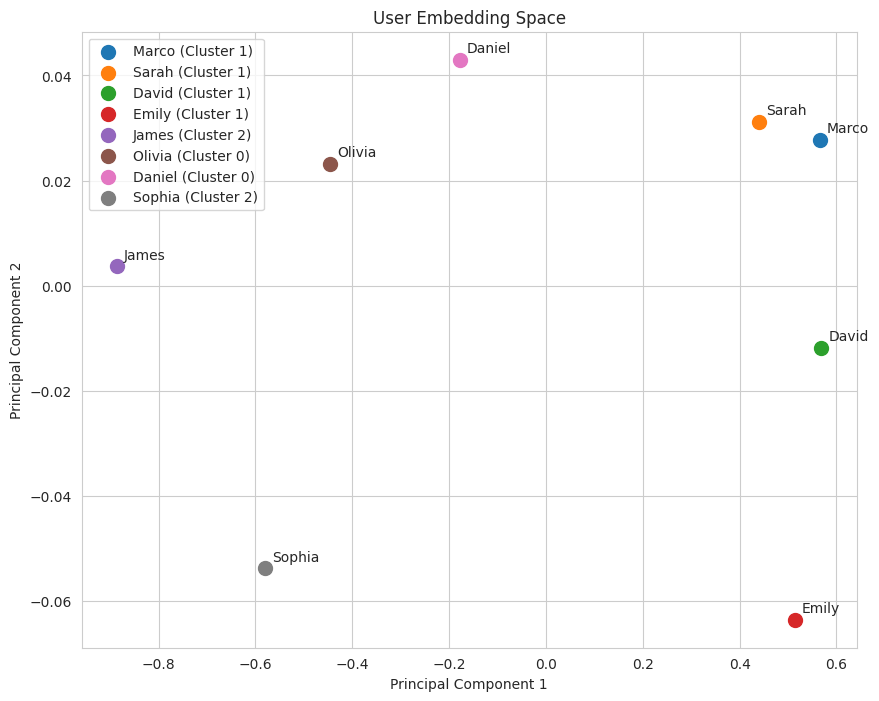

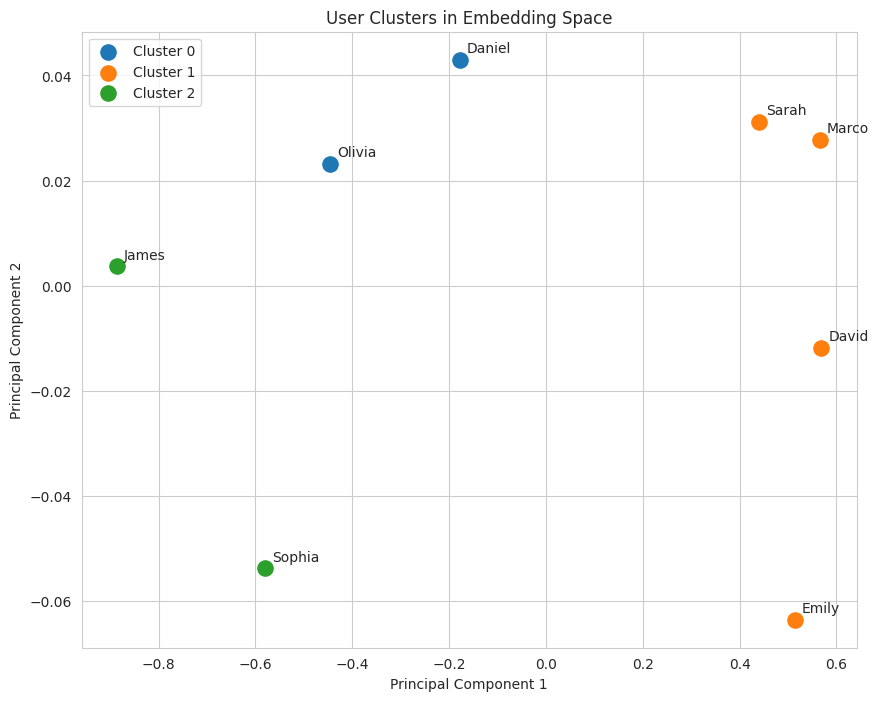

In [80]:
# YOUR CHALLENGE PROJECT CODE HERE

# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import re

# ==========================================
# SUPPORTING COMPONENTS
# ==========================================

def simple_tokenize(text):
    """
    Basic tokenization: split text into words.

    Args:
        text: Input string

    Returns:
        list: Tokens
    """
    # Convert to lowercase
    text = text.lower()

    # Remove punctuation and split
    tokens = re.findall(r'\b\w+\b', text)

    return tokens


class SimpleTokenizer:
    """Simple word tokenizer with a vocabulary."""

    def __init__(self, vocab_size=100):
        self.vocab_size = vocab_size
        self.word_to_id = {}
        self.id_to_word = {}

    def build_vocab(self, texts):
        """
        Build vocabulary from texts.

        Args:
            texts: List of text strings
        """
        # Get all words
        all_words = []

        for text in texts:
            all_words.extend(simple_tokenize(text))

        # Count word frequencies
        word_counts = Counter(all_words)

        # Special tokens
        special_tokens = [
            '<PAD>',
            '<UNK>',
            '<START>',
            '<END>'
        ]

        # Reserve space for special tokens
        most_common = word_counts.most_common(
            self.vocab_size - len(special_tokens)
        )

        # Build vocabulary
        self.word_to_id = {
            word: i
            for i, word in enumerate(special_tokens)
        }

        for i, (word, count) in enumerate(most_common):
            self.word_to_id[word] = (
                i + len(special_tokens)
            )

        # Reverse vocabulary
        self.id_to_word = {
            i: word
            for word, i in self.word_to_id.items()
        }

        print(
            f"Vocabulary built: "
            f"{len(self.word_to_id)} tokens"
        )

    def encode(self, text):
        """
        Convert text to token IDs.

        Args:
            text: Input string

        Returns:
            list: Token IDs
        """
        tokens = simple_tokenize(text)

        unk_id = self.word_to_id['<UNK>']

        return [
            self.word_to_id.get(token, unk_id)
            for token in tokens
        ]

    def decode(self, token_ids):
        """
        Convert token IDs back to text.

        Args:
            token_ids: List of token IDs

        Returns:
            str: Decoded text
        """
        tokens = [
            self.id_to_word.get(
                token_id,
                '<UNK>'
            )
            for token_id in token_ids
        ]

        # Remove special tokens
        tokens = [
            token
            for token in tokens
            if not token.startswith('<')
        ]

        return ' '.join(tokens)


class SimpleEmbedding:
    """Simple word embedding layer."""

    def __init__(self, vocab_size, embedding_dim):
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim

        self.embeddings = (
            np.random.randn(
                vocab_size,
                embedding_dim
            ) * 0.1
        )

    def embed(self, token_ids):
        return self.embeddings[token_ids]

    def similarity(self, id1, id2):
        vec1 = self.embeddings[id1]
        vec2 = self.embeddings[id2]

        dot_product = np.dot(vec1, vec2)

        norm1 = np.linalg.norm(vec1)
        norm2 = np.linalg.norm(vec2)

        return dot_product / (
            norm1 * norm2
        )


def find_similar_words(
    word,
    tokenizer,
    embeddings,
    top_k=5
):
    """
    Find words with similar embedding vectors.
    """

    if word not in tokenizer.word_to_id:
        return None

    word_id = tokenizer.word_to_id[word]

    similarities = []

    for other_word, other_id in tokenizer.word_to_id.items():

        # Ignore special tokens
        if other_word.startswith('<'):
            continue

        # Ignore the word itself
        if other_id == word_id:
            continue

        similarity = embeddings.similarity(
            word_id,
            other_id
        )

        similarities.append(
            (other_word, similarity)
        )

    # Sort from most similar to least similar
    similarities.sort(
        key=lambda x: x[1],
        reverse=True
    )

    return similarities[:top_k]
# ==========================================
# ADVANCED CHALLENGE PROJECT
# STAGE 1: DATA COLLECTION
# ==========================================

# Multiple user profiles for training
user_profiles = [
    {
        "name": "Marco",
        "description": """
        I am an ambitious student studying coding and artificial intelligence.
        I enjoy Python, web development, design and building technology.
        I like running, exercising and working in a quiet environment.
        I value personal growth, creativity, learning and meaningful relationships.
        """
    },

    {
        "name": "Sarah",
        "description": """
        I am a software developer who enjoys programming and building applications.
        I work mainly with Python and JavaScript and I am interested in machine learning.
        I enjoy reading technology books, hiking and spending time with friends.
        I prefer peaceful environments where I can concentrate and learn.
        """
    },

    {
        "name": "David",
        "description": """
        I am interested in artificial intelligence, robotics and computer science.
        I enjoy programming, mathematics and experimenting with new technology.
        I spend my free time playing strategy games, reading and exercising.
        I enjoy solving difficult problems and learning new technical skills.
        """
    },

    {
        "name": "Emily",
        "description": """
        I am a graphic designer and creative professional.
        I love visual design, photography, drawing and creating digital artwork.
        I enjoy music, travelling and meeting creative people.
        I prefer calm environments and enjoy working on creative projects.
        """
    },

    {
        "name": "James",
        "description": """
        I am a fitness enthusiast and personal trainer.
        I enjoy running, weight training, healthy living and outdoor activities.
        I am interested in nutrition, sports science and helping people reach their goals.
        I enjoy energetic environments and spending time with active people.
        """
    },

    {
        "name": "Olivia",
        "description": """
        I am a student interested in psychology, human behaviour and personal development.
        I enjoy reading books, writing, learning about people and having meaningful conversations.
        I also enjoy walking, meditation and spending time in peaceful environments.
        """
    },

    {
        "name": "Daniel",
        "description": """
        I am a web developer who enjoys HTML, CSS, JavaScript and Python.
        I love designing websites and solving programming problems.
        I enjoy technology, entrepreneurship and building useful products.
        I prefer working independently in a quiet environment.
        """
    },

    {
        "name": "Sophia",
        "description": """
        I am passionate about business, entrepreneurship and technology.
        I enjoy developing ideas, building startups and learning about artificial intelligence.
        I like networking, leadership and working with ambitious people.
        I enjoy travelling and discovering new opportunities.
        """
    }
]
print(f"Number of users: {len(user_profiles)}")

print("\nUser profiles:")
for profile in user_profiles:
    print(f"\n{profile['name']}:")
    print(profile['description'].strip())

# Collect only the descriptions for training
training_texts = [
    profile["description"]
    for profile in user_profiles
]

print(f"\nTraining documents: {len(training_texts)}")

# ==========================================
# STAGE 2: TRAINING BETTER EMBEDDINGS
# ==========================================

# Use our collected user descriptions as training data
training_texts = [
    profile["description"]
    for profile in user_profiles
]

print(f"Training on {len(training_texts)} user profiles")

# Tokenize all training data
tokenized_texts = []

for text in training_texts:
    tokens = simple_tokenize(text)
    tokenized_texts.append(tokens)

print("\nTokenized training data:")

for i, tokens in enumerate(tokenized_texts):
    print(f"\n{user_profiles[i]['name']}:")
    print(tokens)

# Build vocabulary from all user descriptions
tokenizer = SimpleTokenizer(vocab_size=100)

tokenizer.build_vocab(training_texts)

print(f"\nVocabulary size: {len(tokenizer.word_to_id)}")

# Creating Training Pairs
def create_skipgram_pairs(tokenizer, texts, window_size=2):
    """
    Create center-word and context-word pairs
    for Skip-gram training.
    """
    training_pairs = []

    for text in texts:
        token_ids = tokenizer.encode(text)

        for i, center_id in enumerate(token_ids):

            start = max(0, i - window_size)
            end = min(len(token_ids), i + window_size + 1)

            for j in range(start, end):

                if i != j:
                    context_id = token_ids[j]
                    training_pairs.append((center_id, context_id))

    return training_pairs

skipgram_pairs = create_skipgram_pairs(
    tokenizer,
    training_texts,
    window_size=2
)

print(f"Number of Skip-gram training pairs: {len(skipgram_pairs)}")

# Improve our training algorithm
def train_skipgram_embeddings(
    tokenizer,
    texts,
    embedding_dim=32,
    window_size=2,
    learning_rate=0.01,
    epochs=100,
    negative_samples=3
):
    """
    Train word embeddings using a simplified
    Skip-gram with negative sampling approach.
    """

    vocab_size = len(tokenizer.word_to_id)

    # Create two embedding matrices
    input_embeddings = np.random.randn(
        vocab_size, embedding_dim
    ) * 0.1

    output_embeddings = np.random.randn(
        vocab_size, embedding_dim
    ) * 0.1

    # Create positive training pairs
    training_pairs = create_skipgram_pairs(
        tokenizer,
        texts,
        window_size
    )

    print(f"Training pairs: {len(training_pairs)}")

    for epoch in range(epochs):

        total_loss = 0

        np.random.shuffle(training_pairs)

        for center_id, context_id in training_pairs:

            center_vector = input_embeddings[center_id]
            context_vector = output_embeddings[context_id]

            # Positive example
            score = np.dot(center_vector, context_vector)

            # Sigmoid
            probability = 1 / (1 + np.exp(-score))

            error = probability - 1

            # Update embeddings
            input_embeddings[center_id] -= (
                learning_rate *
                error *
                context_vector
            )

            output_embeddings[context_id] -= (
                learning_rate *
                error *
                center_vector
            )

            total_loss += -np.log(
                max(probability, 1e-10)
            )

            # Negative samples
            for _ in range(negative_samples):

                negative_id = np.random.randint(vocab_size)

                if negative_id == context_id:
                    continue

                negative_vector = output_embeddings[negative_id]

                negative_score = np.dot(
                    center_vector,
                    negative_vector
                )

                negative_probability = 1 / (
                    1 + np.exp(-negative_score)
                )

                negative_error = negative_probability

                input_embeddings[center_id] -= (
                    learning_rate *
                    negative_error *
                    negative_vector
                )

                output_embeddings[negative_id] -= (
                    learning_rate *
                    negative_error *
                    center_vector
                )

                total_loss += -np.log(
                    max(1 - negative_probability, 1e-10)
                )

        if epoch % 20 == 0:

            average_loss = (
                total_loss /
                len(training_pairs)
            )

            print(
                f"Epoch {epoch}: "
                f"Loss = {average_loss:.4f}"
            )

    # Use the input embeddings as our final word embeddings
    trained_embeddings = SimpleEmbedding(
        vocab_size,
        embedding_dim
    )

    trained_embeddings.embeddings = input_embeddings

    return trained_embeddings

# TRAIN skip-gram
trained_embeddings = train_skipgram_embeddings(
tokenizer,
training_texts,
embedding_dim=32,
window_size=2,
learning_rate=0.01,
epochs=100,
negative_samples=3
)

print("\n✅ Skip-gram embeddings trained!")

# Test skip-gram
test_words = [
    "coding",
    "python",
    "artificial",
    "intelligence",
    "running",
    "design",
    "fitness",
    "technology"
]

print("\nLearned embeddings:")

for word in test_words:
    if word in tokenizer.word_to_id:
        word_id = tokenizer.word_to_id[word]
        embedding = trained_embeddings.embed(
            [word_id]
        )[0]
        print(
            f"{word:15} "
            f"ID={word_id:3} "
            f"Norm={np.linalg.norm(embedding):.4f}"
        )

# Find Skip-gram similar words
for word in ["coding", "technology", "running"]:

    similar = find_similar_words(
        word,
        tokenizer,
        trained_embeddings,
        top_k=5
    )

    print(f"\nWords similar to '{word}':")

    if similar:
        for other_word, similarity in similar:
            print(
                f"  {other_word:15} "
                f"{similarity:.3f}"
              )

# ==========================================
# BONUS: CBOW EMBEDDINGS
# ==========================================

def create_cbow_pairs(tokenizer, texts, window_size=2):
    """
    Create context-word and center-word pairs
    for CBOW training.
    """
    training_pairs = []

    for text in texts:

        token_ids = tokenizer.encode(text)

        for i, center_id in enumerate(token_ids):

            start = max(0, i - window_size)
            end = min(
                len(token_ids),
                i + window_size + 1
            )

            context_ids = [
                token_ids[j]
                for j in range(start, end)
                if j != i
            ]

            if len(context_ids) > 0:
                training_pairs.append(
                    (context_ids, center_id)
                )

    return training_pairs

cbow_pairs = create_cbow_pairs(
    tokenizer,
    training_texts,
    window_size=2
)

print(
    f"Number of CBOW training pairs: "
    f"{len(cbow_pairs)}"
)

# Train CBOW embeddings
def train_cbow_embeddings(
    tokenizer,
    texts,
    embedding_dim=32,
    window_size=2,
    learning_rate=0.01,
    epochs=100
):
    """
    Train word embeddings using a simplified
    CBOW approach.
    """

    vocab_size = len(tokenizer.word_to_id)

    # Create two embedding matrices
    input_embeddings = np.random.randn(
        vocab_size,
        embedding_dim
    ) * 0.1

    output_embeddings = np.random.randn(
        vocab_size,
        embedding_dim
    ) * 0.1

    # Create CBOW training pairs
    training_pairs = create_cbow_pairs(
        tokenizer,
        texts,
        window_size
    )

    print(
        f"CBOW training pairs: "
        f"{len(training_pairs)}"
    )

    for epoch in range(epochs):

        total_loss = 0

        np.random.shuffle(training_pairs)

        for context_ids, center_id in training_pairs:

            # Get context vectors
            context_vectors = input_embeddings[
                context_ids
            ]

            # Average the context vectors
            context_vector = np.mean(
                context_vectors,
                axis=0
            )

            # Get target center-word vector
            center_vector = output_embeddings[
                center_id
            ]

            # Calculate score
            score = np.dot(
                context_vector,
                center_vector
            )

            # Sigmoid
            probability = 1 / (
                1 + np.exp(-score)
            )

            # We want probability close to 1
            error = probability - 1

            # Update context embeddings
            for context_id in context_ids:

                input_embeddings[context_id] -= (
                    learning_rate
                    * error
                    * center_vector
                    / len(context_ids)
                )

            # Update center embedding
            output_embeddings[center_id] -= (
                learning_rate
                * error
                * context_vector
            )

            # Track loss
            total_loss += -np.log(
                max(probability, 1e-10)
            )

        if epoch % 20 == 0:

            average_loss = (
                total_loss /
                len(training_pairs)
            )

            print(
                f"Epoch {epoch}: "
                f"Loss = {average_loss:.4f}"
            )

    # Use input embeddings as final embeddings
    trained_embeddings = SimpleEmbedding(
        vocab_size,
        embedding_dim
    )

    trained_embeddings.embeddings = (
        input_embeddings
    )

    return trained_embeddings

# Train CBOW
cbow_embeddings = train_cbow_embeddings(
    tokenizer,
    training_texts,
    embedding_dim=32,
    window_size=2,
    learning_rate=0.01,
    epochs=100
)

print("\n✅ CBOW embeddings trained!")

# Test CBOW
test_words = [
    "coding",
    "python",
    "artificial",
    "intelligence",
    "running",
    "design",
    "fitness",
    "technology"
]

print("\nCBOW learned embeddings:")

for word in test_words:

    if word in tokenizer.word_to_id:

        word_id = tokenizer.word_to_id[word]

        embedding = cbow_embeddings.embed(
            [word_id]
        )[0]

        print(
            f"{word:15} "
            f"ID={word_id:3} "
            f"Norm={np.linalg.norm(embedding):.4f}"
        )

# Find CBOW similarities
for word in [
    "coding",
    "technology",
    "running"
]:

    similar = find_similar_words(
        word,
        tokenizer,
        cbow_embeddings,
        top_k=5
    )

    print(
        f"\nCBOW words similar to "
        f"'{word}':"
    )

    if similar:

        for other_word, similarity in similar:

            print(
                f"  {other_word:15} "
                f"{similarity:.3f}"
            )

# ==========================================
# STAGE 3: USER EMBEDDING VECTORS
# ==========================================

def create_user_vectors(
    user_profiles,
    tokenizer,
    embeddings
):
    """
    Convert each user profile into
    a single vector using word embeddings.
    """

    user_vectors = []

    for profile in user_profiles:

        # Get the user's description
        description = profile["description"]

        # Convert description into token IDs
        token_ids = tokenizer.encode(description)

        # Convert token IDs into embedding vectors
        word_vectors = embeddings.embed(token_ids)

        # Average all word vectors
        user_vector = np.mean(
            word_vectors,
            axis=0
        )

        user_vectors.append(user_vector)

    return np.array(user_vectors)

user_vectors = create_user_vectors(
    user_profiles,
    tokenizer,
    cbow_embeddings
)

print("\nUser embedding matrix created!")
print(f"Shape: {user_vectors.shape}")
print(f"Number of users: {user_vectors.shape[0]}")
print(f"Embedding dimensions: {user_vectors.shape[1]}")

print("\nUser vector representations:")

for i, profile in enumerate(user_profiles):

    print(
        f"{profile['name']:10} "
        f"→ vector shape: "
        f"{user_vectors[i].shape}"
    )

# Measure Similarity between users
def calculate_user_similarity(
    vector1,
    vector2
):
    """
    Calculate cosine similarity between
    two user vectors.
    """

    return np.dot(vector1, vector2) / (
        np.linalg.norm(vector1)
        * np.linalg.norm(vector2)
    )

print("\nUser similarities:")

for i in range(len(user_profiles)):

    for j in range(i + 1, len(user_profiles)):

        similarity = calculate_user_similarity(
            user_vectors[i],
            user_vectors[j]
        )

        print(
            f"{user_profiles[i]['name']:10} ↔ "
            f"{user_profiles[j]['name']:10} "
            f"= {similarity:.3f}"
        )

# ==========================================
# USER VECTOR DISTANCE DIAGNOSTIC
# ==========================================

def calculate_user_distance(vector1, vector2):
    """
    Calculate Euclidean distance between
    two user vectors.
    """
    return np.linalg.norm(vector1 - vector2)


print("\nUser distances:")

for i in range(len(user_profiles)):

    for j in range(i + 1, len(user_profiles)):

        distance = calculate_user_distance(
            user_vectors[i],
            user_vectors[j]
        )

        print(
            f"{user_profiles[i]['name']:10} ↔ "
            f"{user_profiles[j]['name']:10} "
            f"= {distance:.4f}"
        )

print("\nUser vector statistics:")
print(f"Minimum value: {user_vectors.min():.4f}")
print(f"Maximum value: {user_vectors.max():.4f}")
print(f"Mean value:    {user_vectors.mean():.4f}")
print(f"Std deviation: {user_vectors.std():.4f}")

# ==========================================
# STAGE 4: CLUSTERING
# ==========================================

from sklearn.cluster import KMeans

# Number of clusters
num_clusters = 3

# Create K-Means model
kmeans = KMeans(
    n_clusters=num_clusters,
    random_state=42,
    n_init=10
)

# Train clustering model
cluster_labels = kmeans.fit_predict(user_vectors)

print("\nClustering complete!")
print(f"Number of clusters: {num_clusters}")

print("\nUser clusters:")

for i, profile in enumerate(user_profiles):

    print(
        f"{profile['name']:10} "
        f"→ Cluster {cluster_labels[i]}"
    )

print("\nCluster centers:")
print(kmeans.cluster_centers_.shape)

print("\nCluster members:")

for cluster_id in range(num_clusters):

    members = []

    for i, profile in enumerate(user_profiles):

        if cluster_labels[i] == cluster_id:
            members.append(profile["name"])

    print(
        f"Cluster {cluster_id}: "
        f"{', '.join(members)}"
    )

print("\nCluster sizes:")

for cluster_id in range(num_clusters):

    size = np.sum(
        cluster_labels == cluster_id
    )

    print(
        f"Cluster {cluster_id}: "
        f"{size} users"
    )

# ==========================================
# STAGE 4: RECOMMENDATIONS
# ==========================================

def recommend_users(
    user_index,
    user_profiles,
    user_vectors,
    top_k=3
):
    """
    Recommend users based on
    embedding similarity.
    """

    target_vector = user_vectors[user_index]

    similarities = []

    for i in range(len(user_profiles)):

        # Don't recommend the user themselves
        if i == user_index:
            continue

        similarity = calculate_user_similarity(
            target_vector,
            user_vectors[i]
        )

        similarities.append(
            (i, similarity)
        )

    # Sort from most similar to least similar
    similarities.sort(
        key=lambda x: x[1],
        reverse=True
    )

    return similarities[:top_k]

# Test recommendations for Marco

marco_index = 0

recommendations = recommend_users(
    marco_index,
    user_profiles,
    user_vectors,
    top_k=3
)

print("\nRecommendations for Marco:")

for user_index, similarity in recommendations:

    print(
        f"  {user_profiles[user_index]['name']:10} "
        f"Similarity: {similarity:.3f}"
    )

# TEST WHOLE SYSTEM

print("\nAll user recommendations:")

for i, profile in enumerate(user_profiles):

    recommendations = recommend_users(
        i,
        user_profiles,
        user_vectors,
        top_k=3
    )

    print(
        f"\n{profile['name']} should connect with:"
    )

    for user_index, similarity in recommendations:

        print(
            f"  → {user_profiles[user_index]['name']:10} "
            f"({similarity:.3f})"
        )

# ==========================================
# STAGE 5: VISUALIZATION
# ==========================================

# Reduce our 32-dimensional user vectors
# down to 2 dimensions for visualization

pca = PCA(n_components=2)

user_vectors_2d = pca.fit_transform(user_vectors)

print("\nPCA visualization data:")
print(f"Original dimensions: {user_vectors.shape[1]}")
print(f"Reduced dimensions: {user_vectors_2d.shape[1]}")

# Plot the users

plt.figure(figsize=(10, 8))

for i, profile in enumerate(user_profiles):

    plt.scatter(
        user_vectors_2d[i, 0],
        user_vectors_2d[i, 1],
        s=100,
        label=f"{profile['name']} (Cluster {cluster_labels[i]})"
    )

    plt.annotate(
        profile["name"],
        (
            user_vectors_2d[i, 0],
            user_vectors_2d[i, 1]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title("User Embedding Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)

plt.show()

# Visualize clusters directly

plt.figure(figsize=(10, 8))

for cluster_id in range(num_clusters):

    cluster_points = user_vectors_2d[
        cluster_labels == cluster_id
    ]

    plt.scatter(
        cluster_points[:, 0],
        cluster_points[:, 1],
        s=120,
        label=f"Cluster {cluster_id}"
    )

for i, profile in enumerate(user_profiles):

    plt.annotate(
        profile["name"],
        (
            user_vectors_2d[i, 0],
            user_vectors_2d[i, 1]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title("User Clusters in Embedding Space")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)

plt.show()